In [18]:
# locating the raw data (on julia's laptop)
import os

path = "/home/julia/Argonne/SageBat"

audio_file = os.path.join(path, "20260414_100939.wav")
print(audio_file)

/home/julia/Argonne/SageBat/20260414_100939.wav


## Building the 5,000 × 500 matrix for jeongmin's sparse-representation code

5,000 = `n_samples` (rows), 500 = the size of each sample / `n_features` (cols) —
the standard `(n_samples, n_features)` convention sparse-coding APIs expect
(e.g. scikit-learn's `DictionaryLearning`/`SparseCoder`). So each of the 5,000
rows is one time frame, and its 500 columns are that frame's feature vector.

**Why you can't reshape the raw waveform losslessly.** A 10-min clip at 384 kHz is
384,000 × 600 = 230,400,000 raw samples. The target matrix only holds
5,000 × 500 = 2,500,000 values — ~92× fewer. There's no reshape that keeps all
230M samples inside a 2.5M-slot matrix; something has to give. Two very different
ways to give something up:

1. **Chunk + reshape (numerically lossless, per chunk).** Split the file into
   ~92 non-overlapping blocks of exactly 2,500,000 raw samples and
   `reshape(5000, 500)` each block (each "feature" would just be 500 consecutive
   raw waveform samples). Nothing is discarded — but you get ~92 matrices per
   10-min file, not one.
2. **Downsample the raw waveform to fit one matrix.** Cramming 230M samples into
   2.5M slots means an effective rate of ~4.2 kHz (2,500,000 / 600s). Nyquist caps
   content at ~2 kHz after that — and this is an ultrasonic mic deployed
   specifically to catch bat chirps (20–100+ kHz). That downsampling would erase
   exactly the signal the sensor exists to capture. **Don't do this.**

**Better: spectrogram, as discussed.** A mel-spectrogram is also lossy (magnitude
only, fixed time/frequency resolution) — but it's the *right* kind of lossy: you
choose which axis absorbs the compression (frequency, via mel binning), while
explicitly keeping the full 0–192 kHz bandwidth (`fmax = sr/2`, and no resampling
before the FFT — reuse the native 384 kHz), so bat calls stay inside the analysis
window. The output shape is exactly controllable:
- `hop_length = (sr · duration) / 5000` → 5,000 rows (time frames = samples)
- `n_mels = 500` → 500 columns (frequency bins = features per sample)

One 10-min file → one (5000, 500) matrix, full ultrasonic band represented, no
pre-resampling data loss.

**Remaining trade-off:** 5,000 rows over 600s means ~120 ms of time resolution
per row — chirps landing in the same 120ms frame get merged in time. That's an
inherent consequence of compressing 230M samples into 2.5M matrix cells, not
something avoidable by switching transforms — only the chunk-and-reshape approach
(option 1) sidesteps it, at the cost of many matrices per file instead of one.


In [19]:
import numpy as np
import librosa

def wav_to_fixed_spectrogram_matrix(
    audio_path,
    duration=600.0,       # expected clip length in seconds (10 min files)
    n_time_frames=5000,   # target n_samples (rows)
    n_freq_bins=500,      # target n_features (cols)
    window_s=0.5,         # analysis window length per row, seconds
    fmin=1000,            # Hz, cut very-low-frequency noise/wind
    db_range=80.0,
):
    """
    Native-rate (no resampling) mel-spectrogram, shaped to exactly
    (n_time_frames, n_freq_bins) — i.e. (n_samples, n_features), the
    convention jeongmin's sparse-coding algorithm expects — so a 10-min
    384kHz file maps to one fixed-size matrix without throwing away the
    ultrasonic band. Each of the 5,000 rows is one row spaced 120ms apart,
    built from a `window_s`-second (0.5s) analysis window; its 500 columns
    are that window's mel/frequency feature vector.

    Returns
    -------
    spec : np.ndarray, shape (n_time_frames, n_freq_bins), float32 in [0, 1]
    mel_freqs : np.ndarray, center freq (Hz) of each column
    """
    sr = librosa.get_samplerate(audio_path)
    fmax = sr / 2  # keep full native Nyquist range (no ultrasonic content thrown away)

    # hop_length chosen so the clip maps to exactly n_time_frames rows;
    # n_fft set directly from window_s (0.5s analysis window per row)
    hop_length = int((sr * duration) // n_time_frames)
    n_fft = int(round(window_s * sr))

    data, _ = librosa.load(audio_path, sr=sr, mono=True, duration=duration)
    n_samples = int(duration * sr)
    if len(data) < n_samples:
        data = np.pad(data, (0, n_samples - len(data)))

    S = librosa.feature.melspectrogram(
        y=data, sr=sr,
        n_fft=n_fft, hop_length=hop_length,
        n_mels=n_freq_bins, fmin=fmin, fmax=fmax,
        window="hann",
    )  # (n_freq_bins, time_frames)

    # librosa's centering can produce a frame off by one; force exact shape
    if S.shape[1] > n_time_frames:
        S = S[:, :n_time_frames]
    elif S.shape[1] < n_time_frames:
        S = np.pad(S, ((0, 0), (0, n_time_frames - S.shape[1])))

    S_db = librosa.power_to_db(S, ref=np.max, top_db=db_range)
    spec = ((S_db + db_range) / db_range).astype(np.float32)

    mel_freqs = librosa.mel_frequencies(n_mels=n_freq_bins, fmin=fmin, fmax=fmax)
    return spec.T, mel_freqs  # (n_samples, n_features) = (5000, 500)


In [20]:
matrix, freqs = wav_to_fixed_spectrogram_matrix(audio_file)

print(f"{audio_file}")
print(f"matrix shape: {matrix.shape}  (rows=samples/time frames, cols=features/freq bins)")
print(f"freq range: {freqs[0]:.0f} - {freqs[-1]:.0f} Hz (native Nyquist)")
print(f"value range: [{matrix.min():.3f}, {matrix.max():.3f}]")


/home/julia/Argonne/SageBat/20260414_100939.wav
matrix shape: (5000, 500)  (rows=samples/time frames, cols=features/freq bins)
freq range: 1000 - 192000 Hz (native Nyquist)
value range: [0.401, 1.000]


In [21]:
# known bat chirp in audio_file, from field annotation
chirp_center_s = 289.85
chirp_window_s = 0.25

# which rows of the fixed (5000, 500) matrix cover the chirp window?
row_duration_s = 600.0 / matrix.shape[0]  # seconds/row = 0.12s (matches hop_length)
start_t, end_t = chirp_center_s - chirp_window_s / 2, chirp_center_s + chirp_window_s / 2
row_start, row_end = int(start_t // row_duration_s), int(end_t // row_duration_s)

print(f"chirp window: {start_t:.3f}-{end_t:.3f}s")
print(f"row duration: {row_duration_s * 1000:.0f} ms/row")
print(f"-> falls in matrix rows {row_start}-{row_end} ({row_end - row_start + 1} rows)")

chirp_rows = matrix[row_start:row_end + 1]
print(f"chirp rows value range: [{chirp_rows.min():.3f}, {chirp_rows.max():.3f}]  (whole-matrix mean: {matrix.mean():.3f})")


chirp window: 289.725-289.975s
row duration: 120 ms/row
-> falls in matrix rows 2414-2416 (3 rows)
chirp rows value range: [0.435, 0.876]  (whole-matrix mean: 0.602)


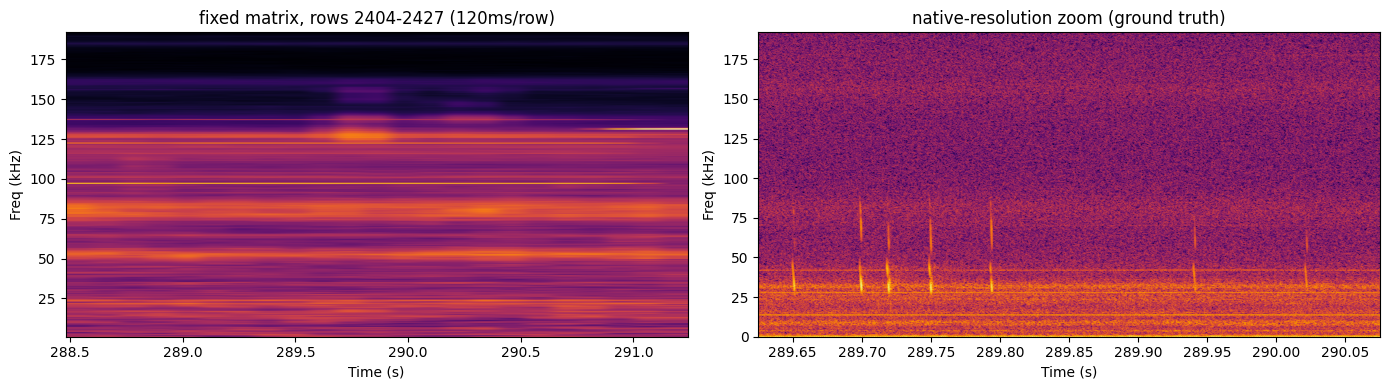

In [22]:
from matplotlib import pyplot as plt

# left: the chirp as it lands in the fixed (5000, 500) matrix, with a few rows
# of context on each side
context_rows = 10
lo = max(0, row_start - context_rows)
hi = min(matrix.shape[0], row_end + 1 + context_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].imshow(
    matrix[lo:hi].T, aspect="auto", origin="lower", cmap="inferno",
    extent=[lo * row_duration_s, hi * row_duration_s, freqs[0] / 1000, freqs[-1] / 1000],
)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Freq (kHz)")
axes[0].set_title(f"fixed matrix, rows {lo}-{hi} (120ms/row)")

# right: native-resolution (384kHz) ground-truth spectrogram over the same
# window, for comparison against what the fixed matrix actually captured
pad = 0.1
hi_data, hi_sr = librosa.load(audio_file, sr=None, mono=True, offset=start_t - pad, duration=(end_t - start_t) + 2 * pad)
S_hi = librosa.stft(hi_data, n_fft=1024, hop_length=64)
S_hi_db = librosa.amplitude_to_db(np.abs(S_hi), ref=np.max)
t_hi = librosa.frames_to_time(np.arange(S_hi.shape[1]), sr=hi_sr, hop_length=64) + (start_t - pad)
f_hi = librosa.fft_frequencies(sr=hi_sr, n_fft=1024)

axes[1].pcolormesh(t_hi, f_hi / 1000, S_hi_db, shading="gouraud", cmap="inferno")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Freq (kHz)")
axes[1].set_title("native-resolution zoom (ground truth)")

plt.tight_layout()
plt.show()


shape: (5000, 500)   dtype: float32   size: 10.0 MB
min=0.401  max=1.000  mean=0.602  std=0.094  median=0.626
fraction of cells < 0.05: 0.0%
fraction of cells < 0.1: 0.0%
fraction of cells < 0.2: 0.0%

most active row (time frame): 2978  (mean=0.621)
most active col (freq bin):   251  (14077 Hz, mean=0.821)


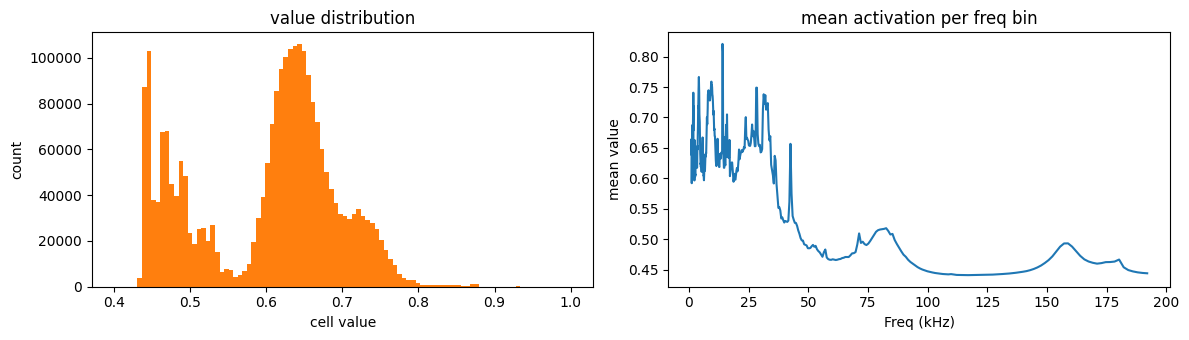

In [23]:
print(f"shape: {matrix.shape}   dtype: {matrix.dtype}   size: {matrix.nbytes / 1e6:.1f} MB")
print(f"min={matrix.min():.3f}  max={matrix.max():.3f}  mean={matrix.mean():.3f}  "
      f"std={matrix.std():.3f}  median={np.median(matrix):.3f}")

for thresh in (0.05, 0.1, 0.2):
    frac = (matrix < thresh).mean()
    print(f"fraction of cells < {thresh}: {frac:.1%}")

row_energy = matrix.mean(axis=1)   # avg activation per time frame
col_energy = matrix.mean(axis=0)   # avg activation per freq bin
print(f"\nmost active row (time frame): {row_energy.argmax()}  (mean={row_energy.max():.3f})")
print(f"most active col (freq bin):   {col_energy.argmax()}  ({freqs[col_energy.argmax()]:.0f} Hz, mean={col_energy.max():.3f})")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist(matrix.ravel(), bins=100, color="tab:orange")
axes[0].set_title("value distribution")
axes[0].set_xlabel("cell value")
axes[0].set_ylabel("count")

axes[1].plot(freqs / 1000, col_energy)
axes[1].set_title("mean activation per freq bin")
axes[1].set_xlabel("Freq (kHz)")
axes[1].set_ylabel("mean value")

plt.tight_layout()
plt.show()
